In [55]:
import sys
sys.path.insert(0, '../') 
import data_generation.SimulatorWaveEquation as simu
import numpy as np
from data_generation import DataPlotter as dp
import matplotlib.pyplot as plt
import os 
import GNN_model_startup.GNN as gnn
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
import torch.nn as nn
import pytorch_lightning as pl
import GNN_model_startup.autoregreesive_roll_out as autoregreesive_roll_out
import GNN_model_startup.onestep_rollout as onestep_rollout
import xarray as xr 

Data set up

In [60]:
R = 1 # Radius 
C = 1 # Wave speed
Lmax = 15 # Maximum degree of spherical harmonics  
generations = 5 # level of refinement for the grid
x0,y0,z0 = R,R,R # Initial position of the gaussian pulse
omega = C/R*np.sqrt(Lmax*(Lmax+1)) 
T_period = 2*np.pi/omega
dt = T_period/10 # Time step 
print("dt =", dt)
tmax = dt*500 # Maximum time

# Initial condition: Gaussian pulse centered at (x0, y0, z0)
def f_handle(x, y, z):
    # dot product with center
    dot = x*x0 + y*y0 + z*z0
    
    cos_alpha = np.clip(dot / R**2, -1.0, 1.0)

    alpha = np.arccos(cos_alpha)
     
    return np.exp(-(alpha**2) / (2*0.2**2))

# Initital condition: zero initial velocity
g_handle = lambda x, y, z: 0 * x

dt = 0.04055778675973611


In [61]:
dt = 0.005

In [62]:
sim = simu.SimulatorWaveEquation(R=1.0, C=C, Lmax=Lmax, tmax=tmax, f_handle=f_handle, g_handle=g_handle, generations=generations,dt=dt)
print("clf val:",sim.clf_value)
print("dt:",sim.dt)
print("dx:",sim.dx)

clf val: 0.14274386708135625
dt: 0.005
dx: 0.03502777458838404


In [47]:
sim.N

10242

In [ ]:
title = f"different_clf/wave_sphere_data_clf{sim.clf_value:.2f}"
ds = sim.simulate(title=title, savedata=True, savegraph=False)  # (time, N) 

In [ ]:
len(ds.time) 

101

## Training data with different clf condition

In [4]:

titles = ["wave_sphere_data_clf0.14.nc",
          "wave_sphere_data_clf0.29.nc",
          "wave_sphere_data_clf0.86.nc",
          "wave_sphere_data_clf1.14.nc",
          "wave_sphere_data_clf1.71.nc",
          "wave_sphere_data_clf3.43.nc"
          ]
nc_path = "../data/nc_files/different_clf"
clf_values = [0.14, 0.29, 0.86, 1.14, 1.71, 3.43]

model = {}
loader = {}
for title, clf in zip(titles, clf_values):
    dataset = gnn.WaveData(data_path=os.path.join(nc_path, f"{title}"))

    # PyG DataLoader batches graphs automatically (no collate_fn needed)
    loader[f"clf_{clf}"] = PyGDataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

    Fin = 1
    Fm = 64

    phi = nn.Sequential(
        nn.Linear(2 * Fin, Fm),
        nn.ReLU(),
        nn.Linear(Fm, Fm),
    )

    psi = nn.Sequential(
        nn.Linear(Fin + Fm, Fm),
        nn.ReLU(),
        nn.Linear(Fm, Fin),
    )

    model[f"clf_{clf}"] = gnn.GNNModel(phi=phi, psi=psi, aggregate="mean", lr=1e-3)


In [ ]:
for clf in clf_values:

    trainer = pl.Trainer(max_training_steps ) 
    trainer.fit(model[f"clf_{clf}"], loader[f"clf_{clf}"]) 
    

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ phi  │ Sequential │  4.4 K │ train │     0 │
│ 1 │ psi  │ Sequential │  4.3 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 8.6 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 8.6 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\maria\OneDrive - Danmarks Tekniske 
Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training batches (7) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

`Trainer.fit` stopped: `max_epochs=50` reached.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ phi  │ Sequential │  4.4 K │ train │     0 │
│ 1 │ psi  │ Sequential │  4.3 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 8.6 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 8.6 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=50` reached.


In [ ]:
def rmse_over_time(ds_pred: xr.Dataset, ds_true: xr.Dataset, steps=None):

    # make sure we compare the same number of time steps
    T_true = ds_true.sizes["time"]
    T_pred = ds_pred.sizes["time"]
    T = min(T_true, T_pred)

    if steps is not None:
        T = min(T, steps + 1)  # +1 because rollout includes initial state

    u_pred = ds_pred["u"].isel(time=slice(0, T))
    u_true = ds_true["u"].isel(time=slice(0, T))

    rmse_t = np.sqrt(((u_pred - u_true) ** 2).mean("grid_index"))
    return rmse_t

In [ ]:
import os
import pandas as pd

results = []
rmse_curves = {}  

steps = 200

for title, clf in zip(titles, clf_values):
    # ensure filename ends with .nc
    fname = title if str(title).endswith(".nc") else f"{title}.nc"
    ds = xr.open_dataset(os.path.join(nc_path, fname))

    # rollout with the matching model
    ds_pred = autoregreesive_roll_out.autoregressive_rollout(
        model[f"clf_{clf}"], ds, steps=steps, device="cpu"
    )

    rmse_t = rmse_over_time(ds_pred, ds, steps=steps)
    rmse_curves[(title, clf)] = rmse_t

    # summary stats
    time_vals = rmse_t["time"].values
    rmse_vals = rmse_t.values

    # relative RMSE normalization (optional but useful)
    true_rms_t = np.sqrt((ds["u"].isel(time=slice(0, len(rmse_t))) ** 2).mean("grid_index"))
    rel_rmse_t = rmse_t / true_rms_t.clip(min=1e-12)

    results.append({
        "title": title,
        "clf": float(clf),
        "dt": float(ds.attrs.get("dt", np.nan)),
        "C": float(ds.attrs.get("C", np.nan)),
        "dx": float(ds.attrs.get("dx", np.nan)),
        "rmse_final": float(rmse_vals[-1]),
        "rmse_mean": float(rmse_vals.mean()),
        #"rmse_auc": float(np.trapz(rmse_vals, x=np.arange(len(rmse_vals)))),  # or use time_vals if numeric
        "rel_rmse_final": float(rel_rmse_t.values[-1]),
        "rel_rmse_mean": float(rel_rmse_t.values.mean()),
    })

df = pd.DataFrame(results).sort_values("clf") 
df 

,title,clf,dt,C,dx,rmse_final,rmse_mean,rel_rmse_final,rel_rmse_mean
0,wave_sphere_data_clf0.14.nc,0.14,0.005,1.0,0.035028,1.845306,0.459580,5.984248,1.463459
1,wave_sphere_data_clf0.29.nc,0.29,0.010,1.0,0.035028,0.246498,0.214793,0.803090,0.622720
2,wave_sphere_data_clf0.86.nc,0.86,0.030,1.0,0.035028,0.430113,0.327966,1.409145,0.972960
3,wave_sphere_data_clf1.14.nc,1.14,0.040,1.0,0.035028,0.319468,0.239444,1.036787,0.711294
4,wave_sphere_data_clf1.71.nc,1.71,0.060,1.0,0.035028,0.340231,0.278518,1.139274,0.819702
5,wave_sphere_data_clf3.43.nc,3.43,0.120,1.0,0.035028,0.236714,0.174895,0.793620,0.518547


In [52]:
import os
import numpy as np
import pandas as pd
import xarray as xr

results = []
rmse_curves = {}

t_end = 10#0.84  # common physical horizon for all dt values

for title, clf in zip(titles, clf_values):
    fname = title if str(title).endswith(".nc") else f"{title}.nc"
    ds = xr.open_dataset(os.path.join(nc_path, fname))

    # Read dt
    dt = float(ds.attrs["dt"])

    # Number of autoregressive steps needed to reach the same physical horizon
    steps_target = int(round(t_end / dt))

    # Cap by available trajectory length
    max_steps_data = ds.sizes["time"] - 1
    steps = min(steps_target, max_steps_data)

    # Roll out model autoregressively
    ds_pred = autoregreesive_roll_out.autoregressive_rollout(
        model[f"clf_{clf}"],
        ds,
        steps=steps,
        device="cpu"
    )

    # Compute RMSE over time
    rmse_t = rmse_over_time(ds_pred, ds, steps=steps)

    # Make sure prediction/truth lengths match safely
    n_times = len(rmse_t)
    rmse_vals = rmse_t.values

    # Relative RMSE: normalize by true RMS at each time
    true_rms_t = np.sqrt(
        (ds["u"].isel(time=slice(0, n_times)) ** 2).mean("grid_index")
    )
    rel_rmse_t = rmse_t / true_rms_t.clip(min=1e-12)

    # Physical time axis
    time_vals = rmse_t["time"].values

    # Roll out step index
    step_vals = np.arange(n_times)

    rmse_curves[(title, clf)] = {
        "rmse_t": rmse_t,
        "rel_rmse_t": rel_rmse_t,
        "time_vals": time_vals,
        "step_vals": step_vals,
        "dt": dt,
        "steps_used": steps,
    }

    results.append({
        "title": title,
        "clf": float(clf),
        "dt": dt,
        "t_end_target": float(t_end),
        "t_end_used": float(time_vals[-1]),
        "steps_target": int(steps_target),
        "steps_used": int(steps),
        "rmse_final": float(rmse_vals[-1]),
        "rmse_mean": float(rmse_vals.mean()),
        "rel_rmse_final": float(rel_rmse_t.values[-1]),
        "rel_rmse_mean": float(rel_rmse_t.values.mean()),
    })

df = pd.DataFrame(results).sort_values(["dt", "clf"]).reset_index(drop=True)

In [53]:
df

,title,clf,dt,t_end_target,t_end_used,steps_target,steps_used,rmse_final,rmse_mean,rel_rmse_final,rel_rmse_mean
0,wave_sphere_data_clf0.14.nc,0.14,0.005,10.0,1.00,2000,200,1.845306,0.459580,5.984248,1.463459
1,wave_sphere_data_clf0.29.nc,0.29,0.010,10.0,1.00,1000,100,0.246498,0.214793,0.803090,0.622720
2,wave_sphere_data_clf0.86.nc,0.86,0.030,10.0,0.99,333,33,0.430113,0.327966,1.409145,0.972960
3,wave_sphere_data_clf1.14.nc,1.14,0.040,10.0,1.00,250,25,0.319468,0.239444,1.036787,0.711294
4,wave_sphere_data_clf1.71.nc,1.71,0.060,10.0,0.96,167,16,0.340231,0.278518,1.139274,0.819702
5,wave_sphere_data_clf3.43.nc,3.43,0.120,10.0,0.96,83,8,0.236714,0.174895,0.793620,0.518547


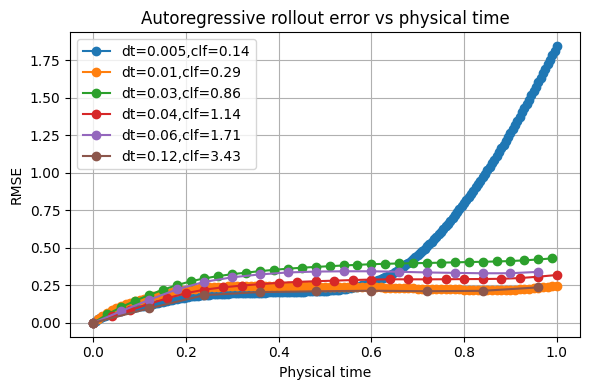

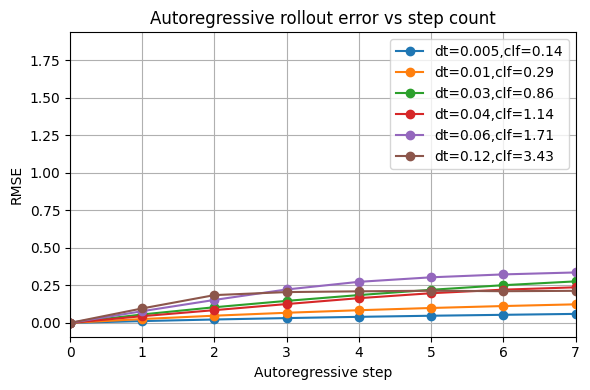

In [ ]:
import matplotlib.pyplot as plt

# RMSE vs physical time
plt.figure(figsize=(6, 4))
for (title, clf), d in rmse_curves.items():
    plt.plot(d["time_vals"], d["rmse_t"],'-o', label=f"dt={d['dt']},clf={clf}")
plt.xlabel("Physical time")
plt.ylabel("RMSE")
plt.title("Autoregressive rollout error vs physical time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# RMSE vs autoregressive step
plt.figure(figsize=(6, 4))
for (title, clf), d in rmse_curves.items():
    plt.plot(d["step_vals"], d["rmse_t"],'-o', label=f"dt={d['dt']},clf={clf}")
plt.xlabel("Autoregressive step")
plt.xlim([0,10])
plt.ylabel("RMSE")
plt.title("Autoregressive rollout error vs step count")
plt.legend() 
plt.grid(True) 
plt.tight_layout() 
plt.show() 